## Post Lab:
 **Perform Regression Task on California Housing Dataset.**


Dataset shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Columns:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Linea

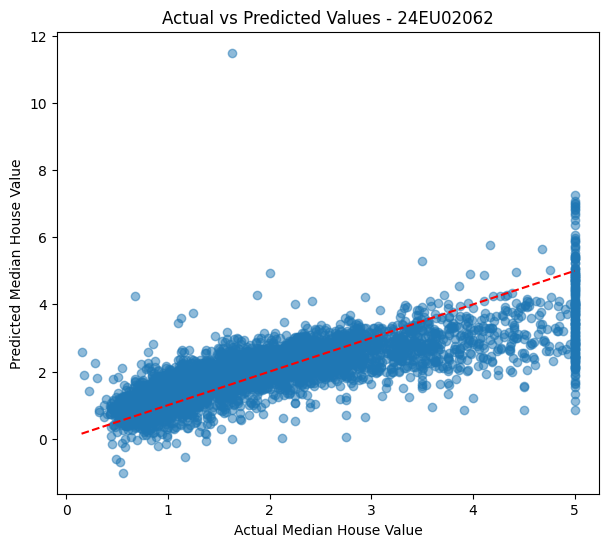


Sample predictions:
    Actual  Predicted
0  0.47700   0.719472
1  0.45800   1.763847
2  5.00001   2.709309
3  2.18600   2.838757
4  2.78000   2.604177
5  1.58700   2.011905
6  1.98200   2.645536
7  1.57500   2.168761
8  3.40000   2.740130
9  4.46600   3.915749


In [1]:
#Post Lab
# California Housing Regression Task

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Dataset shape:", df.shape)
print(df.head())

# 2) Basic info
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

# 3) Split features and target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) Model 1: Linear Regression
lin_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

# 5) Model 2: Ridge Regression
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# 6) Evaluation function
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print(f"MAE : {mae:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")

evaluate_model("Linear Regression", y_test, y_pred_lin)
evaluate_model("Ridge Regression", y_test, y_pred_ridge)

# 7) Compare actual vs predicted for best model
best_pred = y_pred_ridge  # change to y_pred_lin if needed

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred, alpha=0.5)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Values - 24EU02062")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.show()

# 8) Show a few predictions
results = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": best_pred[:10]
})
print("\nSample predictions:")
print(results)